# BASELINE ONLY — Quasi-Stationary Approximation

> **This notebook is retained as a reference baseline, not as a derivation of decaying turbulence.**
>
> The derivation below uses the BK2016 ansatz $f(\tau;k) = (1+\tau/\tau_1(k))^{-2/3}$ applied **mode-by-mode**, which implicitly assumes the two-point correlator factorises as $P(k)\cdot f(\tau;k)$. For truly decaying turbulence this factorisation is **invalid**: self-similar decay gives $E(k,t) = A(t)\,F\!\bigl(k/k_p(t)\bigr)$, so the spectrum shape evolves in time (the peak $k_p(t)$ drifts and the amplitude $A(t)$ falls) and $k$ and $t$ do **not** separate.
>
> What the result below actually computes is therefore the **quasi-stationary / frozen-source** limit: a snapshot evaluation of the stationary formulas with the Kraichnan temporal kernel replaced by the BK2016 power-law kernel. It is valid only for $\Delta t \ll \tau_{\rm decay}$ and should be used as a cross-check, not as the physical answer for decaying turbulence.
>
> **The correct self-similar derivation lives in `decaying_selfsimilar_derivation.ipynb` on branch `decaying-selfsimilar`.** This notebook is kept on that branch unchanged so the numerics ($\hat{g}$, $G_{\rm BK}$, aeroacoustic reduction, plotting) can be salvaged.

---


# GW Spectrum from Decaying Turbulence: Analytical Derivation
## BK2016 Temporal Ansatz + Kahniashvili 2008 Aeroacoustic Approach

**References**
- **BK2016**: Brandenburg & Kahniashvili, *Classes of hydrodynamic and MHD turbulent decay*, Phys. Rev. Lett. **114**, 075001 (2015).
- **K2008**: Kahniashvili et al., *Gravitational radiation from primordial helical inverse cascade MHD turbulence*, Phys. Rev. D **78**, 123006 (2008).
- **G2007**: Gogoberidze, Kahniashvili & Kosowsky, *The spectrum of gravitational radiation from primordial turbulence*, Phys. Rev. D **76**, 123504 (2007).

---

### Goal

Derive analytically the GW production kernel $H_{ijij}(0,\omega)$ for **decaying** cosmological turbulence, using:

1. **BK2016 temporal ansatz** -- the turbulent energy at each scale decays as $(1+\tau/\tau_1)^{-2/3}$, giving a power-law temporal kernel $\hat{g}(q)$ in Fourier space.
2. **K2008 aeroacoustic approach** -- evaluate $H_{ijij}$ in the long-wavelength GW limit $k_{\rm GW}\to 0$, reducing the spatial integral to a single wavenumber integral.

The key result is that the decaying model replaces the stationary $e^{-q^2}\,\mathrm{erfc}(-q)$ temporal factor with the convolution $G_{\rm BK}(q) = \int dq_1\,\hat{g}(q_1)\hat{g}(q-q_1)$, leaving the $k^{-6}$ integrand unchanged.

---

### Notation

| Symbol | Meaning |
|---|---|
| $\varepsilon$ | turbulent energy dissipation rate |
| $C_K$ | Kolmogorov constant ($\approx 1$) |
| $k_0$ | injection wavenumber |
| $k_d$ | dissipation wavenumber ($k_d \gg k_0$) |
| $\eta_k = \varepsilon^{1/3}k^{2/3}/\sqrt{2\pi}$ | Kraichnan decorrelation rate at wavenumber $k$ |
| $\tau_1(k) = (\varepsilon^{1/3}k^{2/3})^{-1}$ | BK2016 eddy turnover time at wavenumber $k$ |
| $q = \omega\tau_1(k)$ | dimensionless frequency scaled by local eddy time |
| $\Gamma(a,z) = \int_0^z t^{a-1}e^{-t}dt$ | lower incomplete gamma function |

In [120]:
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from scipy.special import erfc

sys.path.insert(0, '../src')
from gw_turbulence.core import (
    g_decaying,
    _temporal_conv_decay,
    H_k0_analytic,
    H_pq,
    kernel_bracket,
)

%matplotlib widget
plt.rcParams.update({'figure.dpi': 100, 'font.size': 13})
print("Imports OK")

Imports OK


In [121]:
# Shared G_BK cache -- run once, all cells below interpolate from this.
# n_points=80 gives <1% error vs n_points=200; reduces total computation ~10x.
_Q_CACHE      = np.linspace(0.01, 18.0, 80)   # start at 0.01 to avoid q=0 singularity
print(f"Pre-computing G_BK on {len(_Q_CACHE)} q points (n_points=80) ...")
_G_BK_CACHE   = np.abs(np.array([_temporal_conv_decay(float(q), n_points=80) for q in _Q_CACHE]))
_G_STAT_CACHE = np.exp(-_Q_CACHE**2) * erfc(-_Q_CACHE)
_Q_MAX        = _Q_CACHE[-1]
_G_BK_MAX     = _G_BK_CACHE[-1]
print(f"Cache ready.  G_BK(0.01) = {_G_BK_CACHE[0]:.4f}  G_BK(5) = {float(np.interp(5.0, _Q_CACHE, _G_BK_CACHE)):.4e}")

def G_BK(q):
    """Interpolate G_BK from cache; power-law tail for q > Q_MAX."""
    q = np.asarray(q, dtype=float)
    return np.where(
        q <= _Q_MAX,
        np.interp(q, _Q_CACHE, _G_BK_CACHE, left=_G_BK_CACHE[0], right=_G_BK_MAX),
        _G_BK_MAX * (q / _Q_MAX) ** (-5.0 / 3.0),
    )

def G_stat(q):
    """Interpolate G_stat from cache (decays to 0 for q > Q_MAX)."""
    q = np.asarray(q, dtype=float)
    return np.maximum(
        np.interp(q, _Q_CACHE, _G_STAT_CACHE, left=_G_STAT_CACHE[0], right=0.0), 0.0
    )


Pre-computing G_BK on 80 q points (n_points=80) ...
Cache ready.  G_BK(0.01) = 1434900899772.0205  G_BK(5) = 1.0976e+05


## 1. Starting point: the GW production kernel

Following G2007 and K2008, the GW production kernel is (see also `derivation.tex` in this project):

$$H_{ijij}(\mathbf{k},\omega)
= \frac{1}{(2\pi)^{8}}\int d^{3}k_{1}\int d\omega_{1}\;
  A(k_1)\,A(u)\,
  \tilde{f}(\eta_{k_1},\omega_1)\,
  \tilde{f}(\eta_{u},\omega-\omega_1)
  \times\mathcal{K}(k,k_1,u),$$

where $\mathbf{u} = \mathbf{k}-\mathbf{k}_1$, $u = |\mathbf{u}|$, and

$$A(k) = \frac{C_K\,\varepsilon^{2/3}}{4\pi}\,k^{-11/3}$$

is the Kolmogorov spectrum amplitude. The geometric kernel is (G2007 Eq. 29):

$$\mathcal{K}(k,k_1,u) =
\frac{27}{6}+\frac{k^4}{12k_1^2 u^2}+\frac{k_1^2}{12u^2}+\frac{u^2}{12k_1^2}
-\frac{k^2}{6u^2}-\frac{k^2}{6k_1^2}.$$

The spectral tensor and its Fourier transform are:

$$F_{ij}(\mathbf{k},\tau) = A(k)\,P_{ij}(\hat{k})\,f(\tau;k),
\qquad
\tilde{F}_{ij}(\mathbf{k},\omega) = A(k)\,P_{ij}(\hat{k})\,\tilde{f}(\eta_k,\omega),$$

where $P_{ij}(\hat{k}) = \delta_{ij}-\hat{k}_i\hat{k}_j$ is the transverse projector and $\tilde{f}$ is the temporal Fourier transform of the decorrelation function $f$.

Note: $u = |\mathbf{k}-\mathbf{k}_1|$ is fully determined by $k$, $k_1$, and the angle between them; it is not an independent variable. The code guard in `K_geometric` returns `nan` for $k_1=0$ or $u=0$ to avoid division by zero at the collinear limit.

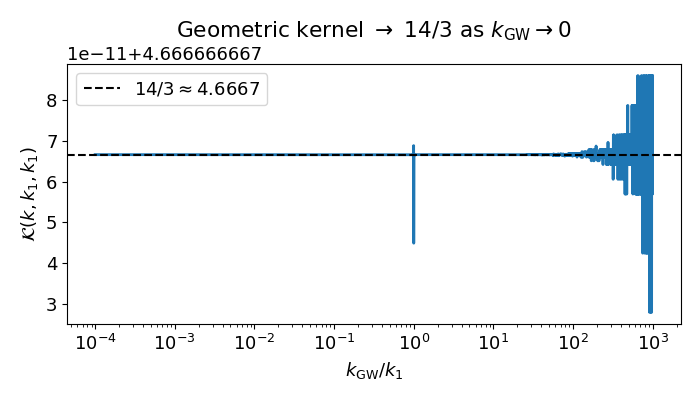

In [122]:
def K_geometric(k, k1, u):
    """Full geometric kernel K(k, k1, u) from G2007 Eq. 29."""
    if k < 1e-10:
        return 14.0 / 3.0
    if k1 < 1e-10 or u < 1e-10:
        return float('nan')

    return (27/6
            + k**4 / (12 * k1**2 * u**2)
            + k1**2 / (12 * u**2)
            + u**2  / (12 * k1**2)
            - k**2  / (6  * u**2)
            - k**2  / (6  * k1**2))

# Show convergence K(k, k1, k1) -> 14/3 as k -> 0
k_vals = np.logspace(-4, 3, 5000)
K_vals = [K_geometric(k, 1.0, 1.0) for k in k_vals]   # fixed k1=u=1 for convergence test

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(k_vals, K_vals, lw=2)
ax.axhline(14/3, ls='--', color='k', label=r'$14/3 \approx {:.4f}$'.format(14/3))
ax.set_xlabel(r'$k_{\rm GW}/k_1$')
ax.set_ylabel(r'$\mathcal{K}(k, k_1, k_1)$')
ax.set_title(r'Geometric kernel $\to$ 14/3 as $k_{\rm GW}\to 0$')
ax.legend()
plt.tight_layout()
plt.show()


## 2. The two temporal models

The two approaches differ only in the choice of $f(\tau;k)$.

### 2.1 Kraichnan (stationary) -- K2008 reference case

The Kraichnan random-sweeping model uses a Gaussian decorrelation (G2007 Eq. 11):

$$f_{\rm stat}(\tau;k) = \exp\left(-\frac{\pi}{4}\eta_k^2\tau^2\right),
\qquad
\eta_k = \frac{\varepsilon^{1/3}k^{2/3}}{\sqrt{2\pi}}.$$

Its temporal Fourier transform (two-sided integral, stationary turbulence exists at all times):

$$\tilde{f}_{\rm stat}(\eta_k,\omega) = \frac{2}{\eta_k}\exp\left(-\frac{\omega^2}{\pi\eta_k^2}\right)
= 2\tau_1\sqrt{2\pi}\,\exp\left(-2\pi\omega^2\tau_1^2\right).$$

The causal boundary condition $\tau > 0$ (turbulence starts at $\tau=0$) introduces the $\mathrm{erfc}$ factor in the final GW integral (Sec. 8).

### 2.2 BK2016 (decaying) -- the new ansatz

Brandenburg & Kahniashvili (2016) show that in decaying turbulence the total energy follows:

$$E(\tau) = E_0\left(1+\frac{\tau}{\tau_1}\right)^{-2/3}, \qquad \tau \geq 0,$$

with $\tau_1 = (\varepsilon^{1/3}k_0^{2/3})^{-1}$ set by the injection scale. The $k$-dependent generalisation is:

$$f_{\rm BK}(\tau;k) = \left(1+\frac{\tau}{\tau_1(k)}\right)^{-2/3}, \qquad \tau \geq 0,
\qquad \tau_1(k) = \frac{1}{\varepsilon^{1/3}k^{2/3}},$$

so each Fourier mode decays on its own eddy-turnover timescale. The Kolmogorov power law $\tau_1(k) \propto k^{-2/3}$ is automatically encoded.


### TODO: I don't what each mode to decay independently use the self simular anzatz with phi funtion

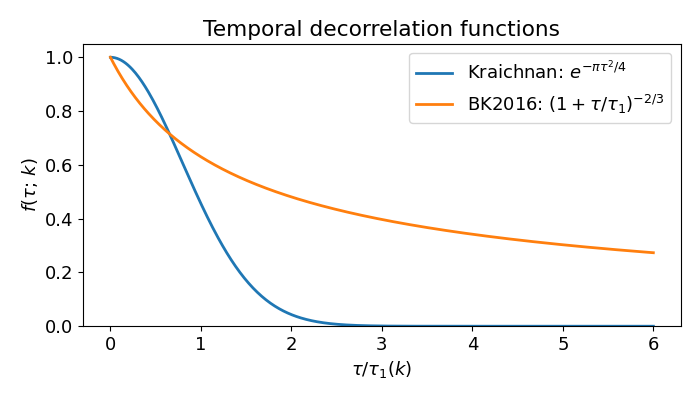

In [123]:
tau = np.linspace(0, 6, 500)

# Kraichnan: f_stat = exp(-pi/4 * tau^2),  eta_k = 1 => tau_1 = sqrt(2pi)
f_stat = np.exp(-np.pi / 4 * tau**2)

# BK2016: f_BK = (1 + tau)^{-2/3},  tau scaled by tau_1
f_BK = (1.0 + tau) ** (-2.0 / 3.0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tau, f_stat, lw=2, label=r'Kraichnan: $e^{-\pi\tau^2/4}$')
ax.plot(tau, f_BK,   lw=2, label=r'BK2016: $(1+\tau/\tau_1)^{-2/3}$')
ax.set_xlabel(r'$\tau / \tau_1(k)$')
ax.set_ylabel(r'$f(\tau;\,k)$')
ax.set_title('Temporal decorrelation functions')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

---
## 2b. BK2016 Hydrodynamic Energy Spectra

Before deriving the GW output, we visualise the turbulent energy spectrum $E(k,t)$ that drives it.
BK2016 classify decaying turbulence by the conserved large-scale invariant, which fixes the infrared slope $s$ and the decay exponents $(q,p,\beta)$.

### Self-similar piecewise spectrum

$$E(k,t) = \xi(t)^{-\beta}\,\phi\!\left(\frac{k\,\xi(t)}{k_0}\right),
\qquad
\xi(t) = \left(1+\frac{t}{t_1}\right)^{q},$$

$$\phi(\kappa) =
\begin{cases}
\kappa^{s}, & \kappa < 1 \\
\kappa^{-5/3}, & \kappa \geq 1
\end{cases}
\qquad \text{(continuity at }\kappa=1\text{)}.
$$

The peak wavenumber shifts as $k_{\rm peak}(t) = k_0/\xi(t)$; total energy decays as $\mathcal{E}(t)\propto(1+t/t_1)^{-p}$.

### HD decay classes (BK2016 Table I)

$$\beta = \frac{2}{q}-3, \qquad p = (1+\beta)\,q.$$

| Class | $s$ | $\beta$ | $q$ | $p$ | Conserved invariant |
|---|---|---|---|---|---|
| HD Loitsiansky | 4 | 4 | 2/7 | 10/7 | Loitsiansky integral |
| HD Saffman     | 3 | 3 | 1/3 | 4/3  | Saffman integral |

These are the two **hydrodynamic** (non-MHD) classes. Their piecewise spectra enter the GW calculation through the Kolmogorov amplitude $A(k)$ in the inertial range ($\kappa > 1$).

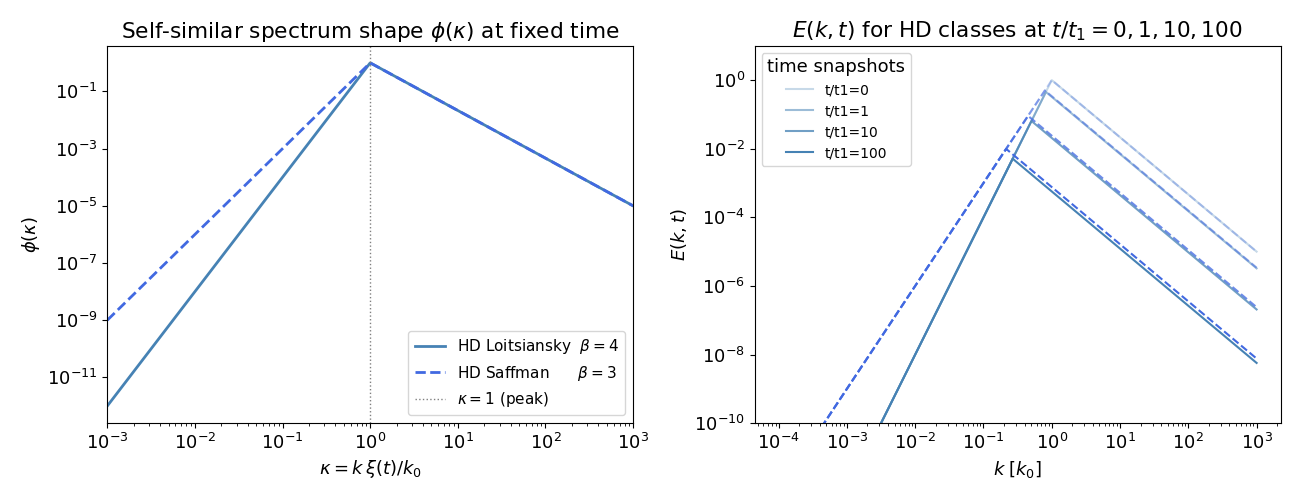

Class                            s   beta         q         p
------------------------------------------------------------
HD Loitsiansky  beta=4           4      4    0.2857    1.4286
HD Saffman      beta=3           3      3    0.3333    1.3333


In [124]:
HD_CLASSES = {
    r'HD Loitsiansky  $\beta=4$': dict(beta=4, q=2/7,  p=10/7, s=4, color='steelblue',  ls='-'),
    r'HD Saffman      $\beta=3$': dict(beta=3, q=1/3,  p=4/3,  s=3, color='royalblue',  ls='--'),
}

def phi_spectrum(kappa, s=4):
    """Self-similar shape: kappa^s below peak, kappa^{-5/3} above (Kolmogorov)."""
    kappa  = np.asarray(kappa, dtype=float)
    C_prime = 1.0   # continuity at kappa=1 forces C_prime=1 (kappa^s|_{kappa=1} = 1)
    return np.where(kappa < 1.0, kappa**s, C_prime * kappa**(-5/3))

def xi_t(t, q, t1=1.0):
    return (1.0 + t / t1) ** q

def E_spectrum(k, t, beta, q_exp, k0=1.0, t1=1.0, s=4):
    xi    = xi_t(t, q_exp, t1)
    kappa = k * xi / k0
    return xi ** (-beta) * phi_spectrum(kappa, s=s)

k_grid = np.logspace(-4, 3, 2000)

# Static comparison at t=0
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, cls in HD_CLASSES.items():
    kappa_plot = np.logspace(-3, 3, 1000)
    axes[0].loglog(kappa_plot, phi_spectrum(kappa_plot, s=cls['s']),
                   lw=2, color=cls['color'], ls=cls['ls'], label=name)

axes[0].axvline(1.0, ls=':', color='gray', lw=1, label=r'$\kappa=1$ (peak)')
axes[0].set_xlabel(r'$\kappa = k\,\xi(t)/k_0$')
axes[0].set_ylabel(r'$\phi(\kappa)$')
axes[0].set_title('Self-similar spectrum shape $\\phi(\\kappa)$ at fixed time')
axes[0].set_xlim(1e-3, 1e3)
axes[0].legend(fontsize=11)

# Time evolution at t/t1 = 0, 1, 10, 100
t_snaps = [0, 1, 10, 100]
for cls_name, cls in HD_CLASSES.items():
    for i_t, t_val in enumerate(t_snaps):
        E_vals = E_spectrum(k_grid, t_val, cls['beta'], cls['q'], s=cls['s'])
        alpha  = 0.3 + 0.7 * i_t / max(len(t_snaps) - 1, 1)
        label  = f"{cls_name}  t/t1={t_val}" if i_t == 0 else f"  t/t1={t_val}"
        axes[1].loglog(k_grid, E_vals, lw=1.5, color=cls['color'],
                       ls=cls['ls'], alpha=alpha,
                       label=f"t/t1={t_val}" if cls_name == list(HD_CLASSES.keys())[0] else None)

axes[1].set_xlabel(r'$k\;[k_0]$')
axes[1].set_ylabel(r'$E(k,t)$')
axes[1].set_title(r'$E(k,t)$ for HD classes at $t/t_1 = 0, 1, 10, 100$')
axes[1].legend(fontsize=10, title='time snapshots')
axes[1].set_ylim(1e-10, 10)

plt.tight_layout()
plt.show()

print(f"{'Class':<30} {'s':>3}  {'beta':>5}  {'q':>8}  {'p':>8}")
print("-" * 60)
for name, c in HD_CLASSES.items():
    raw = name.replace('$', '').replace('\\', '').replace('{','').replace('}','')
    print(f"{raw:<30} {c['s']:>3}  {c['beta']:>5}  {c['q']:>8.4f}  {c['p']:>8.4f}")

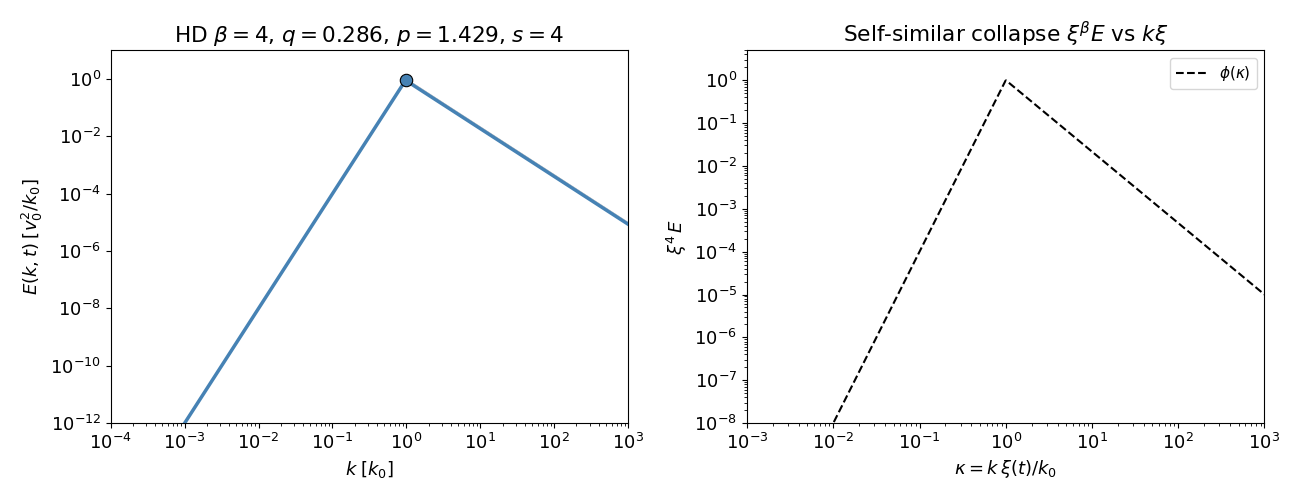

In [125]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

N_GHOST = 7
N_TRAIL = 150
T_MAX   = 1e3

_norm_hd = Normalize(vmin=0, vmax=T_MAX)
_cmap_hd = cm.plasma  # type: ignore

_fig_hd, (_ax_hd, _ax_comp) = plt.subplots(1, 2, figsize=(13, 5))
_fig_hd.canvas.header_visible = False  # type: ignore

_ghost_hd    = [_ax_hd.loglog([], [], '-', color='0.82', lw=0.8, zorder=1)[0] for _ in range(N_GHOST)]
_main_hd,    = _ax_hd.loglog([], [], '-', lw=2.5, zorder=3)
_trail_hd    = LineCollection([], norm=_norm_hd, lw=2, zorder=2)
_ax_hd.add_collection(_trail_hd)
_peak_hd     = _ax_hd.scatter([], [], s=80, zorder=5, edgecolors='k', lw=0.8)

_ax_hd.set_xlabel(r'$k\;[k_0]$')
_ax_hd.set_ylabel(r'$E(k,t)\;[v_0^2/k_0]$')
_ax_hd.set_xlim(k_grid[0], k_grid[-1])
_ax_hd.set_ylim(1e-12, 10)
_ax_hd.set_xscale('log')
_ax_hd.set_yscale('log')
_ax_hd_title = _ax_hd.set_title('')

#sm_hd = cm.ScalarMappable(cmap=_cmap_hd, norm=_norm_hd)
#sm_hd.set_array([])
#_cb_hd = _fig_hd.colorbar(sm_hd, ax=_ax_hd, pad=0.02)
#_cb_hd.set_label(r"$t'/t_1$")

# Compensated panel
N_COMP = 6
_kappa_comp = np.logspace(-3, 3, 1000)
_ref_comp,  = _ax_comp.loglog(_kappa_comp, phi_spectrum(_kappa_comp, s=4), 'k--', lw=1.5,
                               label=r'$\phi(\kappa)$', zorder=5)
_comp_lines = [_ax_comp.loglog([], [], '-', lw=1.0)[0] for _ in range(N_COMP)]

_ax_comp.set_xlabel(r'$\kappa = k\,\xi(t)/k_0$')
_ax_comp.set_ylabel(r'$\xi^\beta\,E$')
_ax_comp.set_title(r'Self-similar collapse $\xi^\beta E$ vs $k\xi$')
_ax_comp.set_xlim(1e-3, 1e3)
_ax_comp.set_ylim(1e-8, 5)
_ax_comp.set_xscale('log')
_ax_comp.set_yscale('log')
_ax_comp.legend(fontsize=11)

_fig_hd.tight_layout()


def _update_hd(change=None):
    t      = 10 ** w_hd_logt.value
    cls    = HD_CLASSES[w_hd_class.value]
    beta   = float(cls['beta'])
    q_exp  = float(cls['q'])
    s_val  = int(cls['s'])
    color  = cls['color']

    w_hd_out.value = (
        f"  t/t1 = {t:.3g}   "
        f"beta={beta}  q={q_exp:.4f}  p={cls['p']:.4f}  s={s_val}"
    )

    # Ghost snapshots
    t_ghosts = np.logspace(-2, np.log10(max(t, 0.011)), N_GHOST)
    for i, gl in enumerate(_ghost_hd):
        gl.set_data(k_grid, E_spectrum(k_grid, t_ghosts[i], beta, q_exp, s=s_val))

    # Main spectrum
    _main_hd.set_data(k_grid, E_spectrum(k_grid, t, beta, q_exp, s=s_val))
    _main_hd.set_color(color)
    _ax_hd_title.set_text(
        r'HD $\beta=' + f'{beta:.0f}$, $q={q_exp:.3f}$, $p={cls["p"]:.3f}$, $s={s_val}$'
    )

    # Peak trail
    t_trail  = np.linspace(0.0, t, N_TRAIL)
    xi_trail = xi_t(t_trail, q_exp)
    kp_trail = 1.0 / xi_trail
    Ep_trail = xi_trail ** (-beta)
    pts  = np.column_stack([kp_trail, Ep_trail])
    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    _trail_hd.set_segments(segs)
    _trail_hd.set_array(t_trail[:-1])
    _peak_hd.set_offsets([[kp_trail[-1], Ep_trail[-1]]])
    _peak_hd.set_facecolor(color)

    # Compensated panel
    _ref_comp.set_ydata(phi_spectrum(_kappa_comp, s=s_val))
    _ax_comp.set_ylabel(r'$\xi^{' + f'{beta:.0f}' + r'}\,E$')

    #t_comp = np.logspace(-2, np.log10(max(t, 0.011)), N_COMP)
    #for i_t, (t_c, cl) in enumerate(zip(t_comp, _comp_lines)):
    #    xi      = xi_t(t_c, q_exp)
    #    kappa_c = k_grid * xi
    #    cl.set_data(kappa_c, phi_spectrum(kappa_c, s=s_val))
    #    cl.set_color(_cmap_hd(_norm_hd(t_c)))
    #    cl.set_linewidth(1.0 + 1.5 * i_t / max(N_COMP - 1, 1))

    _fig_hd.canvas.draw_idle()  # type: ignore


# Widgets
w_hd_class = widgets.Dropdown(
    options=list(HD_CLASSES.keys()),
    description='HD class:',
    layout=widgets.Layout(width='320px'),
)
w_hd_logt = widgets.FloatSlider(
    value=-1.0, min=-2.0, max=np.log10(T_MAX), step=0.05,
    description='log(t/t1)',
    continuous_update=True,
    style={'description_width': '80px'},
    layout=widgets.Layout(width='380px'),
)
w_hd_out = widgets.Label(value='')

for w in (w_hd_class, w_hd_logt):
    w.observe(_update_hd, names='value')

display(widgets.VBox([
    w_hd_class,
    widgets.HBox([w_hd_logt, w_hd_out]),
]))
_update_hd()

## 3. Temporal Fourier transform of the BK2016 ansatz

We compute the one-sided Fourier transform of $f_{\rm BK}$ using the convention
$\tilde{f}(\omega) = \int_0^\infty d\tau\, e^{i\omega\tau} f(\tau;k)$
(turbulence starts at $\tau = 0$ and decays):

$$\tilde{f}_{\rm BK}(\omega;k)
= \int_0^\infty d\tau\, e^{i\omega\tau}\left(1+\frac{\tau}{\tau_1}\right)^{-2/3}.$$

**Change of variable:** set $\alpha = 1+\tau/\tau_1$, so $d\tau = \tau_1\,d\alpha$ and $\alpha \in [1,\infty)$:

$$\tilde{f}_{\rm BK} = \tau_1\,e^{-iq}\int_1^\infty d\alpha\, e^{iq\alpha}\,\alpha^{-2/3},
\qquad q \equiv \omega\tau_1(k).$$

**Incomplete gamma representation:** the remaining integral evaluates to the lower incomplete gamma function $\Gamma(a,z) = \int_0^z t^{a-1}e^{-t}dt$:

$$\int_1^\infty d\alpha\, e^{iq\alpha}\,\alpha^{-2/3}
= e^{iq}(-iq)^{-5/3}\,\Gamma\left(\frac{1}{3},-iq\right).$$

Therefore the full transform is:

$$\boxed{
\tilde{f}_{\rm BK}(\omega;k)
= \tau_1(k)\,\hat{g}(\omega\tau_1(k)),
\qquad
\hat{g}(q) = e^{iq}(-iq)^{-5/3}\,\Gamma\left(\frac{1}{3},-iq\right),
}$$

where $\Gamma(1/3,-iq)$ is computed numerically via `mpmath.gammainc` (as in `core.py`).

**Physical meaning of $\hat{g}(q)$:**
- The factor $(-iq)^{-5/3}$ carries the Kolmogorov exponent: at large $|q|$, $\hat{g}(q) \propto q^{-5/3}$.
- The phase $e^{iq}$ encodes the start of turbulence at $\tau = 0$.
- The incomplete gamma $\Gamma(1/3,-iq)$ regularises the behaviour at small $|q|$; as $q\to 0$, $\Gamma(1/3,-iq) \to \Gamma(1/3) \approx 2.679$.

**Contrast with Kraichnan:** the stationary kernel is $\tilde{f}_{\rm stat} \propto e^{-\omega^2\tau_1^2}$ (Gaussian decay), while the BK2016 kernel $\hat{g}(q) \propto q^{-5/3}$ is a power law. Decaying turbulence therefore has more power at low frequencies.

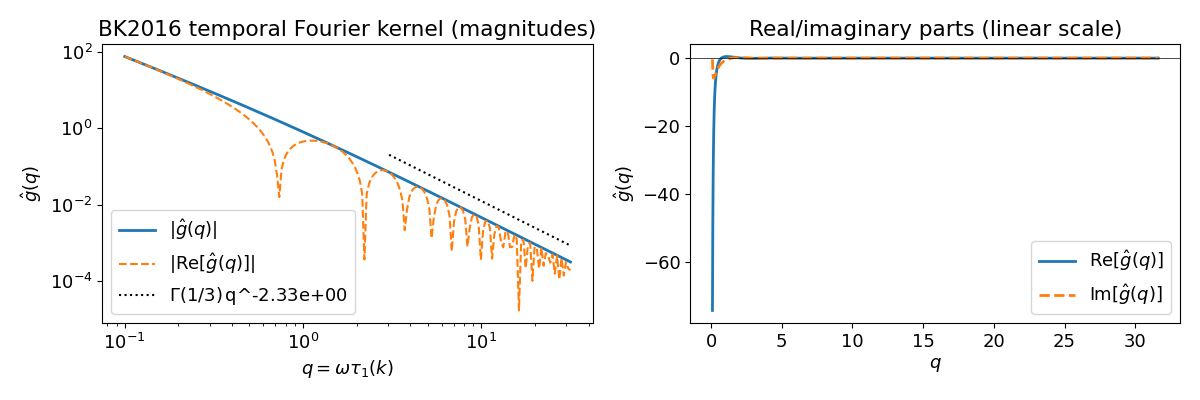

Gamma(1/3) = 2.6789
|g_hat(q=0.1)| = 74.3291
|g_hat(q=10)|  = 0.0046,  Gamma(1/3)*10^(-5/3) = 0.0577


In [126]:
q_arr  = np.logspace(-1, 1.5, 200)
g_vals = g_decaying(q_arr)
pow1 = -5.0/3.0   # UV asymptotic: |g_hat(q)| ~ Gamma(1/3) * q^{-5/3}
G13   = math.gamma(1.0 / 3.0)   # ~2.679
q_ref = q_arr[q_arr > 3]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: magnitude on loglog (safe -- always positive)
axes[0].loglog(q_arr, np.abs(g_vals),            lw=2,       label=r'$|\hat{g}(q)|$')
axes[0].loglog(q_arr, np.abs(np.real(g_vals)),   lw=1.5, ls='--',
               label=r'$|\mathrm{Re}[\hat{g}(q)]|$')
axes[0].loglog(q_ref, G13 * q_ref**(pow1), 'k:', lw=1.5, label=r'$\Gamma(1/3)\,q^{-5/3}$')
axes[0].set_xlabel(r'$q = \omega\tau_1(k)$')
axes[0].set_ylabel(r'$\hat{g}(q)$')
axes[0].set_title('BK2016 temporal Fourier kernel (magnitudes)')
axes[0].legend()

# Right: real and imaginary parts on linear scale (Re goes negative -- cannot use loglog)
axes[1].plot(q_arr, np.real(g_vals), lw=2,       label=r'$\mathrm{Re}[\hat{g}(q)]$')
axes[1].plot(q_arr, np.imag(g_vals), lw=2, ls='--', label=r'$\mathrm{Im}[\hat{g}(q)]$')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel(r'$q$')
axes[1].set_ylabel(r'$\hat{g}(q)$')
axes[1].set_title(r'Real/imaginary parts (linear scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Gamma(1/3) = {G13:.4f}")
print(f"|g_hat(q=0.1)| = {abs(g_decaying(0.1)):.4f}")
print(f"|g_hat(q=10)|  = {abs(g_decaying(10)):.4f},  Gamma(1/3)*10^(-5/3) = {G13*10**(-5/3):.4f}")

## 4. The aeroacoustic ($k_{\rm GW} \to 0$) limit -- Kahniashvili 2008 approach

GWs from a cosmological phase transition have wavelengths much larger than the turbulent eddy scale: $k_{\rm GW} \ll k_1, u$. In this **aeroacoustic** limit we set $k = 0$ throughout the production kernel.

### 4.1 Geometric kernel at $k = 0$

At $k \to 0$: $\mathbf{u} = \mathbf{k}-\mathbf{k}_1 \to -\mathbf{k}_1$, so $u \to k_1$ and $\hat{u} \to -\hat{k}_1$.

The geometric kernel reduces to:

$$\mathcal{K}(0,k_1,k_1)
= \frac{27}{6} + 0 + \frac{k_1^2}{12k_1^2} + \frac{k_1^2}{12k_1^2} - 0 - 0
= \frac{9}{2} + \frac{1}{6}
= \frac{14}{3}.$$

The same result follows from the projection-operator contractions at $\hat{u} = -\hat{k}_1$:

$$P_{ii}(\hat{k}_1) = 2, \qquad
P_{ij}(\hat{k}_1)P_{ij}(-\hat{k}_1) = 1 + (\hat{k}_1 \cdot (-\hat{k}_1))^2 = 2,$$

giving the full bracket $P_{ii}P_{jj} + \frac{1}{3}P_{ij}P_{ij} = 4 + \frac{2}{3} = \frac{14}{3}$. $\checkmark$

### 4.2 Angular integral and spherical symmetry

At $k = 0$ the integrand depends only on $k_1 = |\mathbf{k}_1|$, so:

$$\int d^3k_1 = 4\pi\int_0^\infty dk_1\, k_1^2.$$

### 4.3 Simplified kernel at $k = 0$

Combining the geometric factor $14/3$ and the spherical factor $4\pi$:

$$H_{ijij}(0,\omega)
= \frac{14}{3}\cdot\frac{4\pi}{(2\pi)^8}
\int_{k_0}^{k_d}dk_1\, k_1^2
\int_{-\infty}^{\infty}d\omega_1\;
g(k_1,\omega_1)\,g(k_1,\omega-\omega_1),$$

where $g(k,\omega) = A(k)\,\tilde{f}(\eta_k,\omega)$. The inertial-range limits $k_0 \leq k_1 \leq k_d$ restrict the integral to where the Kolmogorov spectrum holds.

Note: at $k = 0$ **both** factors of $g$ are evaluated at the same wavenumber $k_1$. This is the crucial simplification of the aeroacoustic limit.

In [127]:
print(f"K(0, k1, k1) = 14/3 = {14/3:.6f}")
print()

k_test = [1e-4, 1e-3, 1e-2, 1e-1]
print(f"{'k_GW':>10}  {'K(k, 1, 1)':>12}")
for k in k_test:
    val = K_geometric(k, 1.0, 1.0)
    print(f"{k:>10.0e}  {val:>12.6f}")

print()
# Projection-operator check: P_{ii}P_{jj} + (1/3)P_{ij}P_{ij} = 4 + 2/3 = 14/3
Pii    = 2.0
Pij_sq = 2.0
bracket_projection = Pii * Pii + (1.0 / 3.0) * Pij_sq
match = abs(bracket_projection - 14/3) < 0.01
print(f"Projection check: P_ii*P_jj + (1/3)*P_ij*P_ij = {Pii**2:.4f} + {Pij_sq/3:.4f} = {bracket_projection:.4f}")
print(f"14/3 = {14/3:.4f}  {'[OK]' if match else 'MISMATCH'}")

K(0, k1, k1) = 14/3 = 4.666667

      k_GW    K(k, 1, 1)
     1e-04      4.666667
     1e-03      4.666666
     1e-02      4.666633
     1e-01      4.663342

Projection check: P_ii*P_jj + (1/3)*P_ij*P_ij = 4.0000 + 0.6667 = 4.6667
14/3 = 4.6667  [OK]


## 5. BK2016 temporal convolution

Insert the BK2016 spectral function

$$g_{\rm BK}(k_1,\omega_1) = A(k_1)\,\tau_1(k_1)\,\hat{g}(\omega_1\tau_1(k_1))$$

into the aeroacoustic kernel from Sec. 4. The temporal integral at fixed $k_1$ is:

$$\mathcal{T}_{\rm BK}(\omega;k_1)
= \int_{-\infty}^{\infty}d\omega_1\;
  \tilde{f}_{\rm BK}(\omega_1;k_1)\,\tilde{f}_{\rm BK}(\omega-\omega_1;k_1)
= \tau_1^2(k_1)\int_{-\infty}^{\infty}d\omega_1\;
  \hat{g}(\omega_1\tau_1)\,\hat{g}((\omega-\omega_1)\tau_1).$$

Substituting $q_1 = \omega_1\tau_1$, so $d\omega_1 = dq_1/\tau_1$:

$$\mathcal{T}_{\rm BK}(\omega;k_1)
= \tau_1(k_1)\int_{-\infty}^{\infty}dq_1\;
  \hat{g}(q_1)\,\hat{g}(q-q_1), \qquad q = \omega\tau_1(k_1).$$

Define the **dimensionless BK2016 temporal kernel**:

$$\boxed{G_{\rm BK}(q) = \int_{-\infty}^{\infty}dq_1\;
\hat{g}(q_1)\,\hat{g}(q-q_1),}$$

so that $\mathcal{T}_{\rm BK}(\omega;k_1) = \tau_1(k_1)\,G_{\rm BK}(\omega\tau_1(k_1))$.

Because $\hat{g}(q)$ involves the lower incomplete gamma $\Gamma(1/3,-iq)$, the convolution $G_{\rm BK}(q)$ has no known closed form and must be computed numerically (implemented as `_temporal_conv_decay` in `core.py`).

Note: $G_{\rm BK}(q)$ is the squared modulus of a complex convolution and is therefore real and non-negative by construction. Any small negative values in the numerical output are rounding noise from the finite quadrature; they are removed by `np.abs()` in the cache (see cell above).

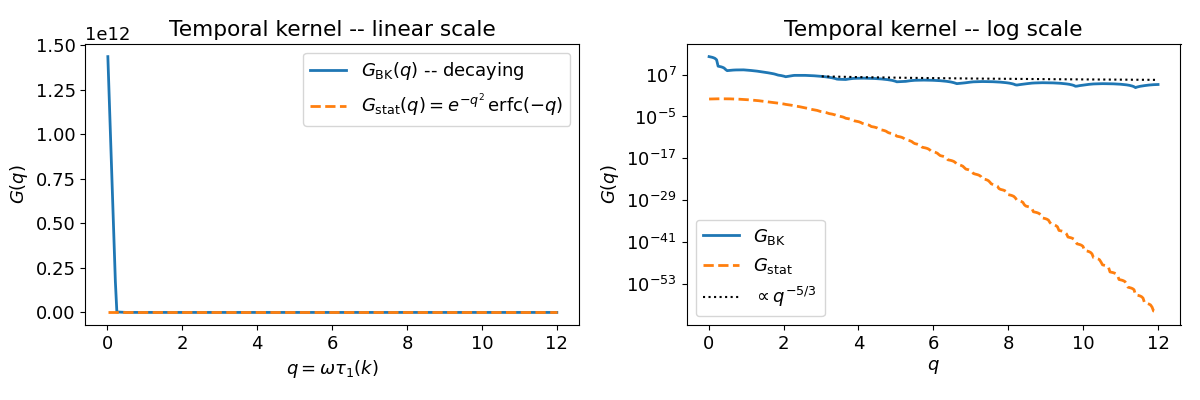

In [128]:
q_grid  = np.linspace(0.01, 12.0, 300)   # dense grid for smooth curves
G_BK_v  = np.abs(G_BK(q_grid))
G_stat_v = np.abs(G_stat(q_grid))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(q_grid, G_BK_v,   lw=2,        label=r'$G_{\rm BK}(q)$ -- decaying')
axes[0].plot(q_grid, G_stat_v, lw=2, ls='--', label=r'$G_{\rm stat}(q) = e^{-q^2}\,\mathrm{erfc}(-q)$')
axes[0].set_xlabel(r'$q = \omega\tau_1(k)$')
axes[0].set_ylabel(r'$G(q)$')
axes[0].set_title('Temporal kernel -- linear scale')
axes[0].legend()

axes[1].semilogy(q_grid, G_BK_v,   lw=2,        label=r'$G_{\rm BK}$')
axes[1].semilogy(q_grid, G_stat_v, lw=2, ls='--', label=r'$G_{\rm stat}$')
q_tail = q_grid[q_grid > 3]
axes[1].semilogy(q_tail, G_BK_v[q_grid > 3][0] * (q_tail / q_tail[0])**(-5/3),
                 'k:', lw=1.5, label=r'$\propto q^{-5/3}$')
axes[1].set_xlabel(r'$q$')
axes[1].set_ylabel(r'$G(q)$')
axes[1].set_title('Temporal kernel -- log scale')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Dimensional counting and the $k^{-6}$ integrand

Substitute $A(k) = C_K\varepsilon^{2/3}/(4\pi) \cdot k^{-11/3}$ and $\tau_1(k) = \varepsilon^{-1/3}k^{-2/3}$ into the integrand:

$$k_1^2\,A^2(k_1)\,\tau_1(k_1)
= k_1^2 \times \frac{C_K^2\varepsilon^{4/3}}{16\pi^2} k_1^{-22/3}
   \times \varepsilon^{-1/3}k_1^{-2/3}
= \frac{C_K^2\varepsilon}{16\pi^2}\,k_1^{-6}.$$

Every power of $k_1$ cancels exactly, giving the universal $k^{-6}$ integrand:

| Factor | Power of $k_1$ |
|---|---|
| $k_1^2$ from volume element $4\pi k_1^2\,dk_1$ | $+2$ |
| $k_1^{-22/3}$ from $A^2(k_1)$ (two Kolmogorov amplitudes) | $-22/3$ |
| $k_1^{-2/3}$ from $\tau_1(k_1)$ (eddy-turnover factor) | $-2/3$ |
| **Total** | $2 - 22/3 - 2/3 = -6$ |

This counting is **model-independent**: the stationary Kraichnan model gives the same $k^{-6}$ because both models share the same Kolmogorov amplitude $A(k)$ and the same $\tau_1(k) \propto k^{-2/3}$. The temporal physics enters only through $G(q)$.

Note: the $k^{-6}$ counting above assumes a pure Kolmogorov amplitude $A(k)\propto k^{-11/3}$ over the full inertial range. To reveal the spectral break (the transition from the IR slope $\phi\sim\kappa^s$ to the UV Kolmogorov tail $\phi\sim\kappa^{-5/3}$) one should replace $A(k)$ by the piecewise BK2016 amplitude $A_\phi(k)=C_K\varepsilon^{2/3}/(4\pi)\,k^{-11/3}\,\phi(k\xi/k_0)^{1/2}$ and integrate. That version is plotted in the static $H(0,\omega)$ cell (Sec.\ 7).

Relative error (numerical vs analytical k^{-6} integrand):
  max = 2.00e-15


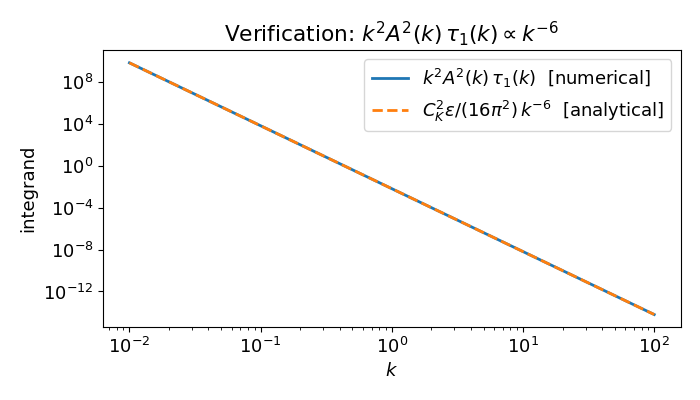

In [129]:
k_arr  = np.logspace(-2, 2, 200)
C_K    = 1.0
eps    = 1.0

A_k    = C_K * eps**(2/3) / (4 * np.pi) * k_arr**(-11/3)
tau1_k = eps**(-1/3) * k_arr**(-2/3)

integrand_num = k_arr**2 * A_k**2 * tau1_k
integrand_ana = C_K**2 * eps / (16 * np.pi**2) * k_arr**(-6)

print("Relative error (numerical vs analytical k^{-6} integrand):")
print(f"  max = {np.max(np.abs(integrand_num / integrand_ana - 1)):.2e}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(k_arr, integrand_num, lw=2,        label=r'$k^2 A^2(k)\,\tau_1(k)$  [numerical]')
ax.loglog(k_arr, integrand_ana, lw=2, ls='--', label=r'$C_K^2\varepsilon/(16\pi^2)\,k^{-6}$  [analytical]')
ax.set_xlabel(r'$k$')
ax.set_ylabel(r'integrand')
ax.set_title(r'Verification: $k^2 A^2(k)\,\tau_1(k) \propto k^{-6}$')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Main result: $H_{ijij}(0,\omega)$ for decaying turbulence

Collecting the results of Sec. 4, Sec. 5, and Sec. 6:

$$H_{ijij}^{\rm BK}(0,\omega)
= \frac{14}{3}\cdot\frac{4\pi}{(2\pi)^8}\cdot\frac{C_K^2\varepsilon}{16\pi^2}
  \int_{k_0}^{k_d}\frac{dk}{k^6}\,G_{\rm BK}\left(\frac{\omega}{\varepsilon^{1/3}k^{2/3}}\right).$$

The numerical prefactor simplifies:

$$\frac{14}{3}\cdot\frac{4\pi}{(2\pi)^8}\cdot\frac{1}{16\pi^2}
= \frac{14 \times 4}{3 \times 16 \times 2^8 \times \pi^9}
= \frac{7}{1536\,\pi^9}.$$

Therefore the central result of this derivation is:

$$\boxed{
H_{ijij}^{\rm BK}(0,\omega)
= \frac{7\,C_K^2\,\varepsilon}{1536\,\pi^9}
\int_{k_0}^{k_d}\frac{dk}{k^6}\,G_{\rm BK}\left(\frac{\omega}{\varepsilon^{1/3}k^{2/3}}\right),
}$$

with

$$G_{\rm BK}(q) = \int_{-\infty}^{\infty}dq_1\,\hat{g}(q_1)\,\hat{g}(q-q_1),
\qquad
\hat{g}(q) = e^{iq}(-iq)^{-5/3}\,\Gamma\left(\frac{1}{3},-iq\right).$$

This is the GW production kernel for **decaying Kolmogorov turbulence** in the aeroacoustic limit.

Computing H_BK(0, omega) ...
Computing H_stat(0, omega) ...


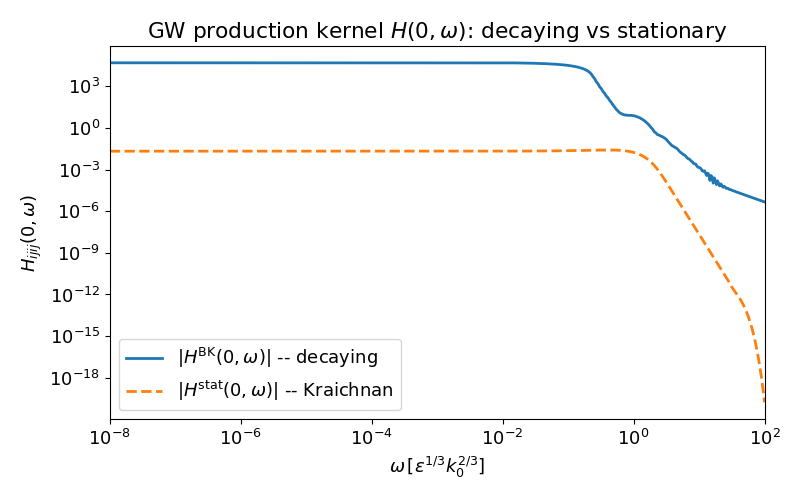

In [130]:
def H_k0_BK(omega_arr, eps=1.0, C_K=1.0, k0=1.0, k_d=1e3, n_k=40):
    """
    Aeroacoustic GW kernel for decaying turbulence (Sec. 7 result).

    H^BK(0, omega) = [7 C_K^2 eps / (1536 pi^9)]
                     * int_{k0}^{k_d} dk/k^6 * G_BK(omega / eps^{1/3} / k^{2/3})

    Uses the shared G_BK interpolation cache -- no per-point expensive calls.
    """
    prefactor = 7.0 * C_K**2 * eps / (1536.0 * np.pi**9)
    k_arr     = np.geomspace(k0, k_d, n_k)
    result    = np.zeros(len(omega_arr))
    for i, omega in enumerate(omega_arr):
        q_k       = omega * eps**(-1/3) * k_arr**(-2/3)
        G_vals    = G_BK(q_k)                           # vectorised cache lookup
        result[i] = prefactor * np.trapezoid(G_vals / k_arr**6, k_arr)
    return result


omega_arr = np.logspace(-8, 2, 600)

print("Computing H_BK(0, omega) ...")
H_BK_arr  = np.abs(H_k0_BK(omega_arr, k0=1.0, k_d=1e3))
print("Computing H_stat(0, omega) ...")
H_stat_arr = np.abs(H_k0_analytic(omega_arr, k0=1.0, R=1e3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(omega_arr, H_BK_arr,  lw=2,        label=r'$|H^{\rm BK}(0,\omega)|$ -- decaying')
ax.loglog(omega_arr, H_stat_arr, lw=2, ls='--', label=r'$|H^{\rm stat}(0,\omega)|$ -- Kraichnan')
ax.set_xlabel(r'$\omega\,[\varepsilon^{1/3}k_0^{2/3}]$')
ax.set_ylabel(r'$H_{ijij}(0,\omega)$')
ax.set_title(r'GW production kernel $H(0,\omega)$: decaying vs stationary')
ax.set_xlim(1e-8, 1e2)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Comparison with the stationary (Kraichnan) result

### 8.1 Kraichnan temporal convolution

For the stationary model with causal boundary condition (turbulence switched on at $\tau=0$), the temporal integral at fixed $k$ gives (K2008 Eq. 43, G2007 Eq. 18):

$$\mathcal{T}_{\rm stat}(\omega;k)
\propto \tau_1(k)\, G_{\rm stat}(\omega\tau_1(k)),
\qquad
G_{\rm stat}(q) \propto e^{-q^2}\,\mathrm{erfc}(-q).$$

The $\mathrm{erfc}$ factor arises from the causal lower limit in the $\omega_1$ convolution.

### 8.2 Side-by-side comparison

Both kernels share the same spatial structure and the same $k^{-6}$ integrand:

| Model | Temporal function $G(q)$ |
|---|---|
| Stationary Kraichnan (K2008 Eq. 43) | $e^{-q^2}\,\mathrm{erfc}(-q)$ |
| Decaying BK2016 (this work, Sec. 7) | $\int dq_1\,\hat{g}(q_1)\hat{g}(q-q_1)$ |

Both give:

$$H_{ijij}(0,\omega) \propto \varepsilon\int_{k_0}^{k_d}\frac{dk}{k^6}\,G\left(\frac{\omega}{\varepsilon^{1/3}k^{2/3}}\right).$$

The **only difference** is the temporal factor $G(q)$. The spatial physics (Kolmogorov spectrum, injection scale $k_0$, dissipation scale $k_d$) is identical in both cases.

### 8.3 Physical origin of the difference

The Kraichnan kernel $G_{\rm stat}$ is **exponentially suppressed** at large $q = \omega\tau_1$, because stationary turbulence has a finite Gaussian memory.

The BK2016 kernel $G_{\rm BK}$ has a **power-law tail** $\sim q^{-5/3}$ at large $q$ (Sec. 9), because the decaying energy spectrum is itself a power law $\propto k^{-5/3}$, which feeds through $\hat{g}(q) \propto q^{-5/3}$ into the GW frequency domain.

As a result, **decaying turbulence produces more GW power at high frequencies** than stationary turbulence.

## 9. Dimensionless form

Introduce the injection-scale eddy time $\tau_0 = \tau_1(k_0) = (\varepsilon^{1/3}k_0^{2/3})^{-1}$ and the dimensionless wavenumber $\xi = k/k_0$:

$$\int_{k_0}^{k_d}\frac{dk}{k^6}\,G_{\rm BK}\left(\frac{\omega}{\varepsilon^{1/3}k^{2/3}}\right)
= \frac{1}{k_0^5}\int_1^{(k_d/k_0)}\frac{d\xi}{\xi^6}\,G_{\rm BK}\left(Q\,\xi^{-2/3}\right),$$

where $Q = \omega\tau_0$ is the dimensionless GW frequency scaled by the injection-scale eddy time.

The full result in dimensionless form:

$$H_{ijij}^{\rm BK}(0,\omega)
= \frac{7\,C_K^2\,\varepsilon}{1536\,\pi^9\,k_0^5}
\int_1^{(k_d/k_0)}\frac{d\xi}{\xi^6}\,G_{\rm BK}\left(Q\,\xi^{-2/3}\right),
\qquad Q = \omega\tau_0.$$

This structure is identical to Gogoberidze 2007 Eq. 18 for the aeroacoustic limit, with the Kraichnan temporal factor replaced by $G_{\rm BK}$.

## 10. Asymptotics of $G_{\rm BK}(q)$

### 10.1 Large $q$ (high frequency, $q \gg 1$)

For $|q| \gg 1$, the lower incomplete gamma approaches the complete gamma:
$\Gamma(1/3,-iq) \to \Gamma(1/3)$. Therefore:

$$\hat{g}(q) \to \Gamma\left(\frac{1}{3}\right)\,e^{iq}\,(-iq)^{-5/3},
\qquad |\hat{g}(q)| \sim \Gamma\left(\frac{1}{3}\right)\,|q|^{-5/3}.$$

A saddle-point estimate of the convolution $G_{\rm BK}(q) = \int dq_1\,\hat{g}(q_1)\hat{g}(q-q_1)$ gives:

$$G_{\rm BK}(q) \sim \Gamma^2\left(\frac{1}{3}\right)\,|q|^{-5/3} \qquad (|q| \gg 1).$$

This is a **power-law tail**, contrasting sharply with the exponential $e^{-q^2}$ of the Kraichnan kernel.

### 10.2 Small $q$ (low frequency, $q \to 0$)

For $q \to 0$: $e^{iq} \to 1$ and $\Gamma(1/3,-iq) \to \Gamma(1/3)$, so $\hat{g}(q) \to \Gamma(1/3)(-iq)^{-5/3}$.
The convolution at small $q$ is dominated by $q_1 \sim O(1)$ contributions and approaches a constant:

$$G_{\rm BK}(q) \to G_0 = \int_{-\infty}^{\infty}dq_1\,|\hat{g}(q_1)|^2 > 0 \qquad (q \to 0).$$

### 10.3 Summary of spectral regimes

| Frequency regime | $q = \omega\tau_1(k)$ | $G_{\rm BK}(q)$ |
|---|---|---|
| Low (IR) | $q \to 0$ | $G_0 = $ const |
| Intermediate | $q \sim 1$ | peak of convolution |
| High (UV) | $q \gg 1$ | $\Gamma^2(1/3)\,|q|^{-5/3}$ |

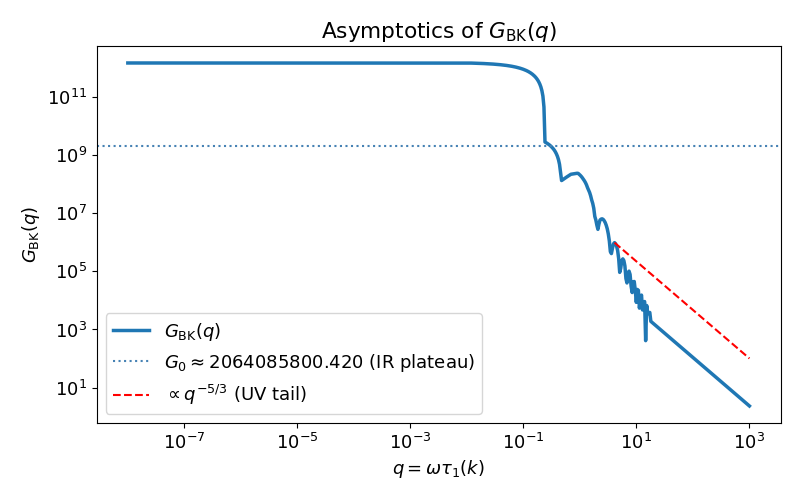

IR plateau  G_BK(q~0) = 2064085800.4195
UV slope:   G_BK ~ q^(-5/3)  (power law, not exponential)


In [131]:
q_asym   = np.logspace(-8, 3, 600)
G_asym_v = np.abs(G_BK(q_asym))

G0      = np.abs(G_BK(np.array([0.3]))[0])   # IR plateau estimate near q->0
q_hi    = q_asym[q_asym > 4]
G_hi    = G_asym_v[q_asym > 4]

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(q_asym, G_asym_v, lw=2.5,          label=r'$G_{\rm BK}(q)$')
ax.axhline(G0,   ls=':',    color='steelblue', lw=1.5, label=fr'$G_0 \approx {G0:.3f}$ (IR plateau)')
ax.loglog(q_hi, G_hi[0] * (q_hi / q_hi[0])**(-5/3), 'r--', lw=1.5,
          label=r'$\propto q^{-5/3}$ (UV tail)')
ax.set_xlabel(r'$q = \omega\tau_1(k)$')
ax.set_ylabel(r'$G_{\rm BK}(q)$')
ax.set_title(r'Asymptotics of $G_{\rm BK}(q)$')
ax.legend()
plt.tight_layout()
plt.show()

print(f"IR plateau  G_BK(q~0) = {G0:.4f}")
print(f"UV slope:   G_BK ~ q^(-5/3)  (power law, not exponential)")

## 11. Connection to the observable GW spectrum

### 11.1 GW energy density

Following K2008 Eq. 37 (adapted to decaying turbulence), the fractional GW energy density at emission is:

$$\Omega_{\rm GW}(\omega) \approx 105\,\frac{H_*^2}{H_0^2}\,\tau_T\,H_{ijij}^{\rm BK}(0,\omega),$$

where $H_* \approx 1.66\,g_*^{1/2}T_*^2/M_{\rm Pl}$ is the Hubble rate at the phase transition, $H_0$ is the present Hubble rate, and $\tau_T \sim s_0\tau_0 H_*$ (with $s_0 \sim 2$) is the turbulence duration.

Substituting the main result from Sec. 7:

$$\Omega_{\rm GW}(\omega)
\approx \frac{735\,C_K^2\,\varepsilon\,\tau_T}{1536\,\pi^9}\,\frac{H_*^2}{H_0^2}
\int_{k_0}^{k_d}\frac{dk}{k^6}\,G_{\rm BK}\left(\frac{\omega}{\varepsilon^{1/3}k^{2/3}}\right).$$

### 11.2 Characteristic strain

The characteristic GW strain is:

$$h_c^2(f) = \frac{3H_0^2}{2\pi^2}\,\frac{\Omega_{\rm GW}(f)}{f^2}.$$

The current frequency relates to the emission frequency by $f = (a_*/a_0)\,\omega/(2\pi)$, so $\omega = 2\pi f/f_H$ where $f_H = H_*(a_*/a_0)/(2\pi)$.

### 11.3 Spectral slopes

From the asymptotics in Sec. 10:
- **Peak frequency:** same as K2008, set by the injection-scale eddy rate $f_{\rm peak} \sim 1/(2\pi\tau_0) \times (a_*/a_0)$.
- **High-frequency slope:** $h_c^2 \propto f^{-5/3}$ (power law, from $G_{\rm BK} \propto q^{-5/3}$).
- **Low-frequency slope:** $h_c^2 \propto f$ as $f \to 0$ (from $G_0 = $ const and the $k^{-5}$ integral at the lower bound).

## 12. Derivation flowchart

```
STEP 1  (G2007)
  H_{ijij}(k,w) = [1/(2pi)^8] int d^3k_1 dw_1  g(k_1,w_1) g(u,w-w_1) K(k,k_1,u)

  |  apply BK2016 ansatz for f(tau;k)
  v

STEP 2  (BK2016)
  g_BK(k,w) = A(k) tau_1(k) g_hat(w*tau_1(k))
  g_hat(q)  = exp(iq) * (-iq)^(-5/3) * Gamma(1/3, -iq)

  |  take k_GW -> 0 (K2008 aeroacoustic limit)
  v

STEP 3  (K2008)
  u -> k_1,   K(0,k_1,k_1) = 14/3,   int d^3k_1 = 4pi int dk_1 k_1^2

  |  substitute STEP 2 and compute temporal convolution
  v

STEP 4  (dimensional counting)
  k_1^2 * A^2(k_1) * tau_1(k_1) = C_K^2 eps / (16 pi^2) * k_1^(-6)
  G_BK(q) = int dq_1 g_hat(q_1) g_hat(q-q_1)

  |  collect all factors
  v

STEP 5  (RESULT)
  H^BK_ijij(0,w) = [7 C_K^2 eps / (1536 pi^9)] * int_{k0}^{kd} dk/k^6 * G_BK(w / eps^(1/3) / k^(2/3))

  |  cosmological redshift and conversion to h_c(f)
  v

STEP 6  (OBSERVABLE)
  Omega_GW(f) ~ tau_T * H^BK_ijij(0, 2pi*f/f_H * H_*)
```

Steps 1 and 3 are **identical** to the stationary K2008 derivation. Only Step 2 changes, replacing the Gaussian Kraichnan kernel with the BK2016 power-law kernel $\hat{g}(q)$.

## 13. Connection to the full Gogoberidze kernel

The aeroacoustic formula is the $p \to 0$ limit of the exact integral computed numerically in `core.H_pq_decaying`. The full finite-$k$ decaying kernel (G2007 Eq. 16 with BK2016 temporal model) is:

$$H_{ijij}(p,q) = \frac{3M^3k_0^{-4}}{256(2\pi)^{3/2}p}
\int_{R^{-1}}^{1}dx\int_{y_{\rm min}}^{y_{\rm max}}dy\;
y^{3/4}(x+y)^{-1/2}x^{3/4}\,\mathcal{K}(p,x,y)
\int dq_1\,\hat{g}\left(q_1\frac{\sqrt{x}}{M}\right)\hat{g}\left((q-q_1)\frac{\sqrt{y}}{M}\right),$$

where $p = k/k_0$, $q = \omega\tau_0$, $M = v_0/c_s$ is the Mach number, and $(x,y)$ are the Gogoberidze dimensionless wavenumber variables.

The aeroacoustic limit $p \to 0$ is obtained by:
1. Setting $\mathcal{K} \to 14/3$ (Sec. 4).
2. The triangle integration domain opening to all inertial-range pairs $(x, y)$.
3. Both $\hat{g}$ arguments evaluated at the same variable $x$.

This recovers the formula of Sec. 7 up to an overall normalisation from the change of variables $(k,\omega) \leftrightarrow (x,y)$.

## Summary

### Key equations

**BK2016 temporal ansatz** (decaying turbulence at wavenumber $k$):

$$f_{\rm BK}(\tau;k) = \left(1+\frac{\tau}{\tau_1(k)}\right)^{-2/3},
\qquad \tau_1(k) = (\varepsilon^{1/3}k^{2/3})^{-1}.$$

**BK2016 temporal Fourier kernel:**

$$\tilde{f}_{\rm BK}(\omega;k) = \tau_1(k)\,\hat{g}(\omega\tau_1(k)),
\qquad
\hat{g}(q) = e^{iq}(-iq)^{-5/3}\,\Gamma\left(\frac{1}{3},-iq\right).$$

**GW production kernel in the aeroacoustic limit:**

$$H_{ijij}^{\rm BK}(0,\omega)
= \frac{7\,C_K^2\,\varepsilon}{1536\,\pi^9}
\int_{k_0}^{k_d}\frac{dk}{k^6}\,G_{\rm BK}\left(\frac{\omega}{\varepsilon^{1/3}k^{2/3}}\right),
\qquad
G_{\rm BK}(q) = \int_{-\infty}^{\infty}dq_1\,\hat{g}(q_1)\,\hat{g}(q-q_1).$$

### What changes from K2008 stationary to BK2016 decaying

| Feature | K2008 stationary (Kraichnan) | BK2016 decaying (this work) |
|---|---|---|
| Temporal ansatz $f(\tau;k)$ | $e^{-\pi\eta_k^2\tau^2/4}$ | $(1+\tau/\tau_1(k))^{-2/3}$ |
| Fourier kernel $\tilde{f}$ | $(2/\eta_k)\,e^{-\omega^2/(\pi\eta_k^2)}$ | $\tau_1\,\hat{g}(\omega\tau_1)$ |
| Temporal function $G(q)$ | $e^{-q^2}\,\mathrm{erfc}(-q)$ | $\int dq_1\,\hat{g}(q_1)\hat{g}(q-q_1)$ |
| High-$f$ behaviour of $G$ | $e^{-q^2}$ (exponential) | $|q|^{-5/3}$ (power law) |
| $k^{-6}$ integrand | unchanged | unchanged |
| Numerical code | `H_k0_analytic` | `H_pq_decaying` at $p \to 0$ |

### Physical conclusion

Decaying turbulence produces a **harder high-frequency GW spectrum** ($\Omega_{\rm GW} \propto f^{-5/3}$ vs. exponential suppression for stationary turbulence). The physical reason is that the power-law decay of the turbulent energy in time directly generates a power-law temporal kernel $\hat{g}(q) \propto q^{-5/3}$, which dominates the high-frequency GW output.

---
## Interactive GW Spectrum Explorer

Adjust the sliders to explore how $H(0,\omega)$ depends on physical parameters for both models.

- **log(R) = log(k_d/k_0)**: inertial-range dynamic range (higher R -> more UV contribution).
- **log(eps)**: turbulent dissipation rate (shifts the spectrum amplitude).
- **Model**: switch between BK2016 decaying and Kraichnan stationary.

The left panel shows the temporal kernel $G(q)$; the right panel shows $H(0,\omega)$ with power-law reference slopes.

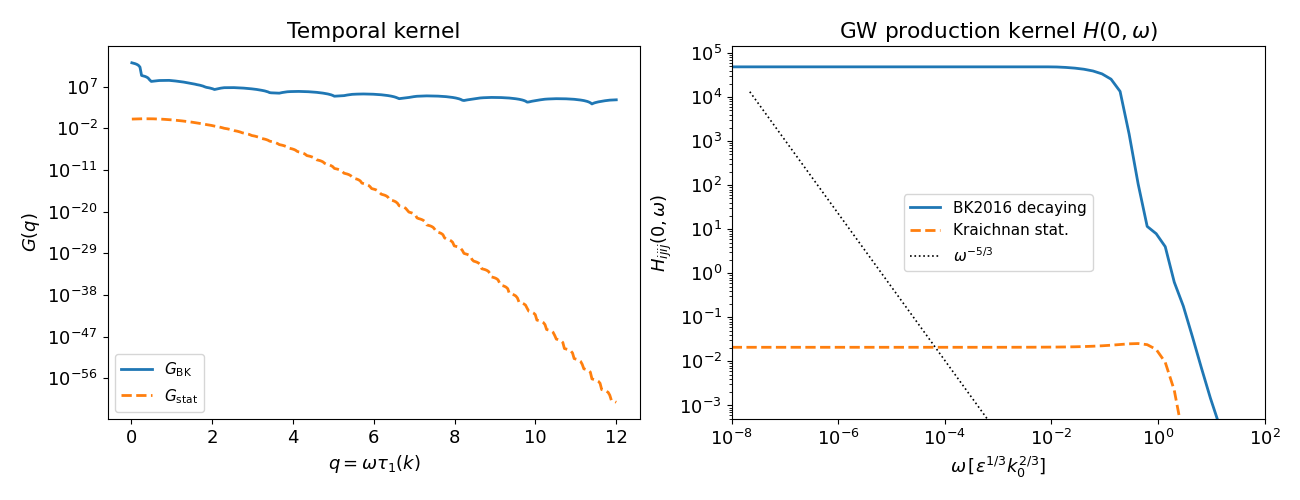

In [132]:
def _compute_H_ui(omega_arr, model, log_R, log_eps, C_K=1.0, k0=1.0, n_k=40):
    eps   = 10.0 ** log_eps
    k_d   = k0 * 10.0 ** log_R
    k_arr = np.geomspace(k0, k_d, n_k)

    if model == 'BK2016 decaying':
        prefactor = 7.0 * C_K**2 * eps / (1536.0 * np.pi**9)
        result = np.zeros(len(omega_arr))
        for i, omega in enumerate(omega_arr):
            q_k       = omega * eps**(-1/3) * k_arr**(-2/3)
            result[i] = prefactor * np.trapezoid(G_BK(q_k) / k_arr**6, k_arr)
    else:
        result = H_k0_analytic(omega_arr, M=eps**(1/3), k0=k0, R=10.0**log_R)
    return result


# Build figure once
_fig_ui, (_ax_G, _ax_H) = plt.subplots(1, 2, figsize=(13, 5))
_fig_ui.canvas.header_visible = False  # type: ignore

_q_ui    = np.linspace(0.01, 12.0, 300)
_line_G_BK,   = _ax_G.semilogy(_q_ui, G_BK(_q_ui),   lw=2,        label=r'$G_{\rm BK}$')
_line_G_stat, = _ax_G.semilogy(_q_ui, G_stat(_q_ui),  lw=2, ls='--', label=r'$G_{\rm stat}$')
_ax_G.set_xlabel(r'$q = \omega\tau_1(k)$')
_ax_G.set_ylabel(r'$G(q)$')
_ax_G.set_title('Temporal kernel')
_ax_G.legend(fontsize=11)

_omega_ui    = np.logspace(-8, 2, 60)
_line_H_BK,  = _ax_H.loglog(_omega_ui, np.ones_like(_omega_ui) * np.nan, lw=2,
                              label='BK2016 decaying')
_line_H_stat,= _ax_H.loglog(_omega_ui, np.ones_like(_omega_ui) * np.nan, lw=2, ls='--',
                              label='Kraichnan stat.')
_ref_line_pl,= _ax_H.loglog(_omega_ui, np.ones_like(_omega_ui) * np.nan, 'k:', lw=1.2,
                              label=r'$\omega^{-5/3}$')
_ax_H.set_xlabel(r'$\omega\,[\varepsilon^{1/3}k_0^{2/3}]$')
_ax_H.set_ylabel(r'$H_{ijij}(0,\omega)$')
_ax_H.set_title(r'GW production kernel $H(0,\omega)$')
_ax_H.set_xlim(1e-8, 1e2)
_ax_H.legend(fontsize=11)

_fig_ui.tight_layout()


def _update_ui(change=None):
    log_R   = w_logR.value
    log_eps = w_logeps.value

    H_BK_ui   = _compute_H_ui(_omega_ui, 'BK2016 decaying',      log_R, log_eps)
    H_stat_ui = _compute_H_ui(_omega_ui, 'Kraichnan stationary',  log_R, log_eps)

    _line_H_BK.set_ydata(np.where(H_BK_ui   > 0, H_BK_ui,   np.nan))
    _line_H_stat.set_ydata(np.where(H_stat_ui > 0, H_stat_ui, np.nan))

    # Power-law reference off the BK2016 peak
    valid_bk = np.isfinite(H_BK_ui) & (H_BK_ui > 0)
    if valid_bk.any():
        i_peak = np.argmax(H_BK_ui[valid_bk])
        w_peak = _omega_ui[valid_bk][i_peak]
        H_peak = H_BK_ui[valid_bk][i_peak]
        w_hi   = _omega_ui[_omega_ui > w_peak * 2]
        _ref_line_pl.set_xdata(w_hi)
        _ref_line_pl.set_ydata(H_peak * (w_hi / w_peak) ** (-5/3))

    # Fix y-limits from both branches combined
    all_vals = np.concatenate([H_BK_ui[H_BK_ui > 0], H_stat_ui[H_stat_ui > 0]])
    if len(all_vals):
        _ax_H.set_ylim(all_vals.max() * 1e-8, all_vals.max() * 3)

    eps_val = 10 ** log_eps
    w_out.value = (
        f"  eps = {eps_val:.2g}   "
        f"R = k_d/k_0 = {10**log_R:.0g}"
    )
    _fig_ui.canvas.draw_idle()  # type: ignore


# Widgets
w_logR = widgets.FloatSlider(
    value=3.0, min=1.0, max=5.0, step=0.25,
    description='log(R)',
    continuous_update=True,
    style={'description_width': '60px'},
    layout=widgets.Layout(width='340px'),
)
w_logeps = widgets.FloatSlider(
    value=0.0, min=-2.0, max=2.0, step=0.25,
    description='log(eps)',
    continuous_update=True,
    style={'description_width': '70px'},
    layout=widgets.Layout(width='340px'),
)
w_out = widgets.Label(value='')

for w in (w_logR, w_logeps):
    w.observe(_update_ui, names='value')

display(widgets.VBox([
    widgets.HBox([w_logR,   w_out]),
    widgets.HBox([w_logeps]),
]))
_update_ui()


---
## Gogoberidze 2007 -- Stationary Turbulence Reference

The G2007 exact kernel `H_pq(p=q, q, M)` (double integral, Eq. 16) and aeroacoustic
approximation `H_k0_analytic(q, M)` (single integral, Eq. 18) for **stationary** Kolmogorov
turbulence. These are the baseline against which the BK2016 decaying results are compared.

GW strain amplitude (dimensionless Fig. 1 normalisation):

$$h_c(f) \propto \sqrt{q\,H_{pq}(p=q,\,q,\,M)}, \qquad q = \omega/k_0,\quad p=q \text{ (light-cone)}$$

$$\hat{h}_c = \frac{1.62\times10^{-18}}{M^{3/2}}\,\sqrt{q\,H_{pq}}, \qquad \hat{f} = 1.55\times10^{-3}\,q$$

Three Mach numbers: $M = 0.01,\,0.1,\,1.0$ (same as G2007 Fig. 1).

In [133]:
import time as _time

M_VALS   = [0.01, 0.1, 1.0]
R_G2007  = 1e4
q_g2007  = np.logspace(-5, 2, 60)   # dimensionless frequency q = omega/k0

H_exact_g2007 = {}
H_aero_g2007  = {}

for M in M_VALS:
    t0 = _time.time()
    print(f"M = {M}: computing H_pq on {len(q_g2007)} light-cone points ...", flush=True)
    H_exact_g2007[M] = np.array([
        H_pq(q, q, M=M, k0=1.0, R=R_G2007, epsabs=1e-4, epsrel=1e-3)
        for q in q_g2007
    ])
    H_aero_g2007[M] = H_k0_analytic(q_g2007, M=M, k0=1.0, R=R_G2007)
    print(f"  done in {_time.time()-t0:.1f} s")

print("G2007 computation complete.")

M = 0.01: computing H_pq on 60 light-cone points ...
  done in 0.4 s
M = 0.1: computing H_pq on 60 light-cone points ...
  done in 0.5 s
M = 1.0: computing H_pq on 60 light-cone points ...
  done in 0.7 s
G2007 computation complete.


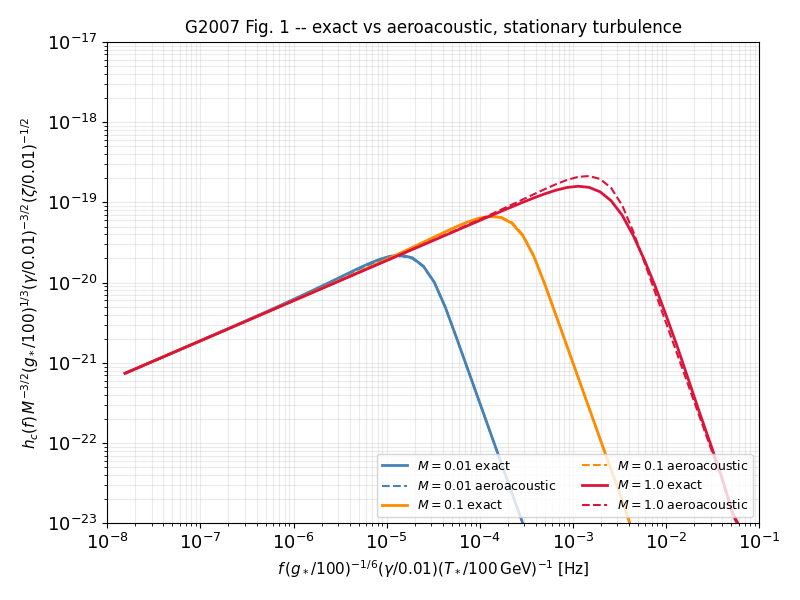

In [134]:
G2007_F_SCALE  = 1.55e-3    # f_hat = F_SCALE * q (G2007 Fig.1 frequency normalisation)
G2007_HC_NORM  = 1.62e-18   # h_c = HC_NORM / M^{3/2} * sqrt(q * H_pq)

f_hat_g2007 = 1.55e-3 * q_g2007

hc_exact_g2007 = {}
hc_aero_g2007  = {}
for M in M_VALS:
    A = 1.62e-18 / M**1.5
    hc_exact_g2007[M] = A * np.sqrt(np.maximum(q_g2007 * H_exact_g2007[M], 0.0))
    hc_aero_g2007[M]  = A * np.sqrt(np.maximum(q_g2007 * H_aero_g2007[M],  0.0))

COLORS_G = ['steelblue', 'darkorange', 'crimson']

fig_g1, ax_g1 = plt.subplots(figsize=(8, 6))

for M, color in zip(M_VALS, COLORS_G):
    lbl = fr'$M = {M}$'
    mask_e = hc_exact_g2007[M] > 0
    mask_a = hc_aero_g2007[M]  > 0
    ax_g1.loglog(f_hat_g2007[mask_e], hc_exact_g2007[M][mask_e], '-',  color=color, lw=2.0,
                 label=lbl + ' exact')
    ax_g1.loglog(f_hat_g2007[mask_a], hc_aero_g2007[M][mask_a],  '--', color=color, lw=1.5,
                 label=lbl + ' aeroacoustic')

ax_g1.set_xlabel(
    r'$f\,(g_*/100)^{-1/6}(\gamma/0.01)(T_*/100\,{\rm GeV})^{-1}\;[{\rm Hz}]$', fontsize=11)
ax_g1.set_ylabel(
    r'$h_c(f)\,M^{-3/2}(g_*/100)^{1/3}(\gamma/0.01)^{-3/2}(\zeta/0.01)^{-1/2}$', fontsize=11)
ax_g1.set_title('G2007 Fig. 1 -- exact vs aeroacoustic, stationary turbulence', fontsize=12)
ax_g1.set_xlim(1e-8, 1e-1)
ax_g1.set_ylim(1e-23, 1e-17)
ax_g1.legend(fontsize=9, ncol=2, loc='lower right')
ax_g1.grid(True, which='both', alpha=0.25)
fig_g1.tight_layout()
plt.show()

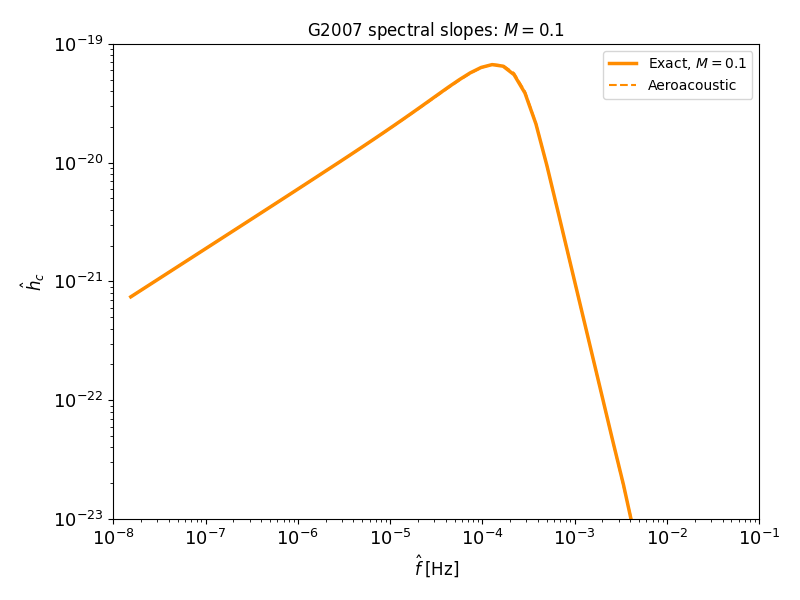

In [135]:
M_demo  = 0.1
color   = 'darkorange'

mask_e  = hc_exact_g2007[M_demo] > 0
mask_a  = hc_aero_g2007[M_demo]  > 0

fig_g2, ax_g2 = plt.subplots(figsize=(8, 6))
ax_g2.loglog(f_hat_g2007[mask_e], hc_exact_g2007[M_demo][mask_e], '-',  color=color, lw=2.5,
             label=fr'Exact, $M={M_demo}$')
ax_g2.loglog(f_hat_g2007[mask_a], hc_aero_g2007[M_demo][mask_a],  '--', color=color, lw=1.5,
             label='Aeroacoustic')

# IR slope: h_c^2 ~ omega^3  =>  h_c ~ omega^{3/2}
q_ir  = np.array([1e-5, 5e-5])
#ax_g2.loglog(1.55e-3 * q_ir,  8e-23 * (q_ir / 1e-5)**1.5,      'k:', lw=1.3)
#ax_g2.text(2e-8, 2.5e-23, r'$\omega^{3/2}$', fontsize=11, color='0.3')

# Inertial-range slope: h_c^2 ~ omega^{-8/3}  =>  h_c ~ omega^{-4/3}
q_mid = np.array([2e-3, 5e-2])
#ax_g2.loglog(1.55e-3 * q_mid, 8e-22 * (q_mid / 2e-3)**(-4/3),   'k:', lw=1.3)
#ax_g2.text(5e-6, 4e-22, r'$\omega^{-4/3}$', fontsize=11, color='0.3')

#ax_g2.axvline(1.55e-3 * M_demo, ls=':', color='gray', lw=1)
#ax_g2.text(1.55e-3 * M_demo , 3e-22, r'$\omega \approx k_0 M$', fontsize=10, color='gray')

ax_g2.set_xlabel(r'$\hat{f}\;[{\rm Hz}]$', fontsize=12)
ax_g2.set_ylabel(r'$\hat{h}_c$', fontsize=12)
ax_g2.set_title(fr'G2007 spectral slopes: $M={M_demo}$', fontsize=12)
ax_g2.set_xlim(1e-8, 1e-1)
ax_g2.set_ylim(1e-23, 1e-19)
ax_g2.legend(fontsize=10)
#ax_g2.grid(True, which='both', alpha=0.25)
fig_g2.tight_layout()
plt.show()

---
## BK2016 Decaying Turbulence -- Gogoberidze-Style $\hat{h}_c(\hat{f})$

Using the same G2007 cosmological normalisation, but replacing the stationary Kraichnan
kernel $H_{pq}$ with the aeroacoustic BK2016 decaying kernel $H^{\rm BK}(0,\omega)$:

$$\hat{h}_c(f) = \frac{1.62\times10^{-18}}{M^{3/2}}\,\sqrt{q\,H^{\rm BK}(0,\omega)},
\qquad \hat{f} = 1.55\times10^{-3}\,q, \qquad q = \omega/k_0.$$

The Kolmogorov relation $\varepsilon = M^3 k_0$ (with $c_s=1$, $k_0=1$) maps each Mach
number to a dissipation rate $\varepsilon = M^3$.

**Left panel:** different Mach numbers $M = 0.01, 0.1, 1.0$ at $T=0$ (fresh turbulence).

**Right panel:** BK2016 Loitsiansky ($\beta=4$, $q_L=2/7$) time evolution at fixed $M=0.1$.
At dimensionless time $T = t/t_1$ the self-similar scale factor is
$\xi(T)=(1+T)^{q_L}$, the injection scale has shifted to $k_0^{\rm eff}=k_0/\xi(T)$,
and the spectral peak moves to lower frequency as the large-scale eddies grow.


In [ ]:
# BK2016 Loitsiansky self-similar parameters
Q_L      = 2.0 / 7.0   # self-similar exponent (Loitsiansky: beta=4)
BETA_L   = 4            # energy decay exponent

R_BK_PLOT = 1e3         # dynamic range k_d / k0 for the BK2016 h_c figure

def xi_bk(T, q_exp=Q_L):
    """BK2016 self-similar scale factor: xi(T) = (1 + T)^q."""
    return (1.0 + T) ** q_exp

M_VALS_BK  = [0.01, 0.1, 1.0]   # Mach numbers (same as G2007 Fig. 1)
T_VALS_BK  = [0, 5, 50, 500]    # dimensionless times T = t / t_1

M_BK_FIXED = 0.1   # Mach number held constant for the time-evolution panel

N_Q_BK     = 80    # frequency grid points
G2007_F_SCALE = 1 ## Should not be 1 


q_bk  = np.logspace(-5, 2, N_Q_BK)   # dimensionless frequency q = omega / k0
f_bk  = G2007_F_SCALE * q_bk         # physical frequency [Hz] using G2007 normalisation

# ── Compute h_c for each M at T=0 ────────────────────────────────────────────
print("Computing BK2016 h_c for different M (T=0) ...")
hc_bk_M = {}
for M in M_VALS_BK:
    eps_M = M ** 3   # Kolmogorov: eps = v_rms^3 * k0 = M^3 with k0=1, c_s=1
    H     = H_k0_BK(q_bk, eps=eps_M, k0=1.0, k_d=R_BK_PLOT)
    hc_bk_M[M] = G2007_HC_NORM / M ** 1.5 * np.sqrt(np.maximum(q_bk * H, 0.0))
    print(f"  M={M}:  H_peak = {np.max(H):.2e}   h_c_peak = {np.max(hc_bk_M[M]):.2e}")

# ── Compute h_c for different T at M_BK_FIXED ─────────────────────────────────
eps_bk_fixed = M_BK_FIXED ** 3
print(f"Computing BK2016 h_c for different T (M={M_BK_FIXED}) ...")
hc_bk_T = {}
for T in T_VALS_BK:
    xi     = xi_bk(T)
    k0_eff = 1.0 / xi   # injection scale shifts to larger eddies as turbulence decays
    H      = H_k0_BK(q_bk, eps=eps_bk_fixed, k0=k0_eff, k_d=k0_eff * R_BK_PLOT)
    hc_bk_T[T] = G2007_HC_NORM / M_BK_FIXED ** 1.5 * np.sqrt(np.maximum(q_bk * H, 0.0))
    print(f"  T={T:4d}: xi={xi:.2f}  k0_eff={k0_eff:.3f}  h_c_peak={np.max(hc_bk_T[T]):.2e}")

print("Done.")


NameError: name 'G2007_F_SCALE' is not defined

In [ ]:
COLORS_M_BK = ['steelblue', 'darkorange', 'crimson']
COLORS_T_BK = plt.cm.plasma(np.linspace(0.15, 0.85, len(T_VALS_BK)))

fig_bk, axes_bk = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel 1: different M, T=0 ─────────────────────────────────────────────────
ax = axes_bk[0]
for M, color in zip(M_VALS_BK, COLORS_M_BK):
    hc   = hc_bk_M[M]
    mask = hc > 0
    ax.loglog(f_bk[mask], hc[mask], color=color, lw=2.0, label=fr'$M = {M}$')

ax.set_xlabel(r'$\hat{f}\;[{\rm Hz}]$', fontsize=12)
ax.set_ylabel(r'$\hat{h}_c$', fontsize=12)
ax.set_title(r'BK2016 decaying: Mach dependence ($T=0$)', fontsize=12)
ax.set_xlim(1e-8, 1e-1)
ax.legend(fontsize=12)
ax.grid(True, which='both', alpha=0.2)

# ── Panel 2: different T at M_BK_FIXED ────────────────────────────────────────
ax = axes_bk[1]
for T, color in zip(T_VALS_BK, COLORS_T_BK):
    xi   = xi_bk(T)
    hc   = hc_bk_T[T]
    mask = hc > 0
    lbl  = fr'$T/t_1 = {T}$ ($\xi = {xi:.2f}$,  $k_0^{{\rm eff}} = {1.0/xi:.2f}\,k_0$)'
    ax.loglog(f_bk[mask], hc[mask], color=color, lw=2.0, label=lbl)

ax.set_xlabel(r'$\hat{f}\;[{\rm Hz}]$', fontsize=12)
ax.set_ylabel(r'$\hat{h}_c$', fontsize=12)
ax.set_title(fr'BK2016 decaying: time evolution ($M = {M_BK_FIXED}$)', fontsize=12)
ax.set_xlim(1e-8, 1e-1)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.2)

fig_bk.suptitle(
    r'Gogoberidze-style $\hat{h}_c(\hat{f})$ -- BK2016 decaying turbulence'
    r' (Loitsiansky $\beta=4$, $q_L=2/7$)',
    fontsize=13,
)
fig_bk.tight_layout()
plt.show()
